# Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
rc('font',size=18)

In [2]:
#from pynitride.devices import gan_pfet
from pynitride.paramdb import nm,cm, k, eV
from pynitride.mesh import Mesh, MaterialBlock, UniformLayer
from pynitride.material import AlGaN, Insulator
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop, Linear_Fermi
from pynitride.strain import Pseudomorphic
from pynitride.thermal import ConstantT
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP
from pynitride.visual import sublog

# Define

In [3]:
from pynitride.paramdb import pmdb
a=pmdb["AlN.conditions=relaxed.lattice.a"]
strainconds={}
strainconds[   'asgrown']= { 'ax':1.00*a, 'ay':1.00*a }
strainconds[ 'biax_comp']= { 'ax':0.99*a, 'ay':0.99*a }
strainconds[ 'biax_tens']= { 'ax':1.01*a, 'ay':1.01*a }
strainconds['uniax_comp']= { 'ax':0.99*a, 'ay':1.00*a }
strainconds['uniax_tens']= { 'ax':1.01*a, 'ay':1.00*a }

In [4]:
import pixiedust

Pixiedust database opened successfully


In [7]:
#%%pixie_debugger
sims={}
for k,v in strainconds.items():
    with sublog("Solving at strain condition "+k):
        sim=sims[k]={}

        # Define mesh
        m=Mesh(
            [
                #MaterialBlock(Insulator("SiO2"),[
                #    UniformLayer("diel",7*nm)
                #]),
                MaterialBlock("epi",AlGaN(),[
                    UniformLayer("well",5*nm,exx=.01),
                    UniformLayer("subs",500*nm,x=1,DeepDonorDonorConc=5.0e16/cm**3)
                ])
            ],
            max_dz=10*nm,
            refinements=[#["diel/well",.01*nm,5],
                         ["well/subs",.01*nm,1.6]],
            boundary=[1*eV,'thick']
        )
        #_,shm,scm=m.submesh_cover([7*nm,20*nm])
        shm,scm=m.matblock("epi").mesh.submesh_cover([8*nm])

        Pseudomorphic(m.matblock("epi").mesh)
        ConstantT(m)
        fermisolver=Equilibrium(m)
        poissonsolver=PoissonSolver(m)
        carriersolvers1=[Schrodinger(shm,carriers=['hole']),
                         Semiclassical(shm,carriers=['electron']),
                         Semiclassical(scm)]
        mbkp=sim['mbkp']=MultibandKP(shm,ktmax=2.5,num_eigenvalues=6,num_kpoints=25)
        carriersolvers2=[mbkp]+carriersolvers1[1:]

        #print(m.matblock("epi").mesh._attrs)
        #m.matblock("epi").mesh['T']

        m.initialize()

        #m.function_chart([m.matblock("epi").mesh,shm])

        #print(m._functions.keys())
        #print(shm.T)
        for solver in [fermisolver,poissonsolver]+carriersolvers1+[mbkp]:#+carriersolvers2:
            solver.initialize()

        fermisolver.solve()
        sc=SelfConsistentLoop(fieldsolvers=[poissonsolver],carriersolvers=carriersolvers1)
        sc.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.005)


        # This is some sort of boundary condition not sure what... not huge effect on density
        for H in mbkp._H:
            H[:6,:6]*=2
            H[-6:,-6:]*=2
        scl=SelfConsistentLoop(fieldsolvers=[poissonsolver],carriersolvers=carriersolvers2)
        scl.loop(tol=1e-8)

        #print(m.p)
        break

Solving at strain condition asgrown
Assembling k.p matrices ...
Done assembly.
  Starting eps factor ramp from 1000 to 1
    Eps factor: 1.00e+03
    Starting SC loop
      iter:   0  err: 1.01e-14  activ: 1
      Loop finished in  1 iterations with err=1.01076e-14
    Eps factor: 6.31e+02
    Starting SC loop
      iter:   0  err: 2.53e-03  activ: 1
      iter:   1  err: 2.39e-15  activ: 1
      Loop finished in  2 iterations with err=2.38814e-15
    Eps factor: 2.51e+02
    Starting SC loop
      iter:   0  err: 1.03e-02  activ: 1
      iter:   1  err: 1.35e-14  activ: 1
      Loop finished in  2 iterations with err=1.35014e-14
    Eps factor: 7.94e+01
    Starting SC loop
      iter:   0  err: 3.72e-02  activ: 1
      iter:   1  err: 2.90e-14  activ: 1
      Loop finished in  2 iterations with err=2.89699e-14
    Eps factor: 2.51e+01
    Starting SC loop
      iter:   0  err: 1.18e-01  activ: 1
      iter:   1  err: 5.80e-14  activ: 1
      Loop finished in  2 iterations with err=5.

      iter:   1  err: 9.22e-02  activ: 1
      Retrying with Poisson activation=0.5
             iter:   1  err: 5.77e-02
      iter:   2  err: 2.99e-02  activ: 0.6
      iter:   3  err: 1.21e-02  activ: 0.72
      iter:   4  err: 3.40e-03  activ: 0.864
      iter:   5  err: 4.63e-04  activ: 1
      iter:   6  err: 3.93e-07  activ: 1
      Loop finished in  7 iterations with err=3.92877e-07
    Eps factor: 1.31e+00
    Starting SC loop
      iter:   0  err: 4.25e-01  activ: 1
      iter:   1  err: 1.14e-01  activ: 1
      iter:   2  err: 6.30e-02  activ: 1
      iter:   3  err: 8.39e-02  activ: 1
      Retrying with Poisson activation=0.5
             iter:   3  err: 7.33e-02
      Retrying with Poisson activation=0.25
             iter:   3  err: 6.16e-02
      iter:   4  err: 5.04e-02  activ: 0.3
      iter:   5  err: 3.86e-02  activ: 0.36
      iter:   6  err: 2.72e-02  activ: 0.432
      iter:   7  err: 1.71e-02  activ: 0.5184
      iter:   8  err: 9.15e-03  activ: 0.62208
      it

# Solve

1.5628745250630647


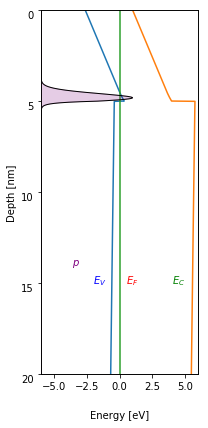

In [8]:
def fig_pFET_bd(ax):
    ax.plot(m.Ev,m.zp)
    ax.plot(m.Ec,m.zp)
    ax.plot(m.EF,m.zp)
    ax.set_yticks(np.linspace(0,20,5))
    ax.set_ylim(20,0)
    ax.set_ylabel("Depth [nm]")
    #plt.gca().yaxis.set_label_position("right")
    #plt.gca().yaxis.tick_right()
    ax.set_xlim(-6,6)
    plt.setp(ax.get_yticklabels(),va='top')
    #plt.gca().add_artist(Ellipse((-4,5.5),3,6,facecolor='none',edgecolor='k'))
    #plt.gca().add_artist(Ellipse((5,5.5),3,6,facecolor='none',edgecolor='k'))
    
    ax.set_xlabel("Energy [eV]")
    ax.xaxis.set_label_coords(.5,-.1)
    ax.text(4,15,"$E_C$",color='g',transform=ax.transData)
    ax.text(-2,15,"$E_V$",color='b',transform=ax.transData)
    ax.text(.5,15,"$E_F$",color='r',transform=ax.transData)
    
    ax2=ax.twiny()
    xmax=500
    ax2.plot(m.p*(1e7)**3/1e18,m.zp,'k',linewidth=1)
    ax2.fill_betweenx(m.zp,m.p*(1e7)**3/1e18,color='purple',alpha=.2)
    ax2.set_xlim(0,xmax)
    ax2.set_xticks([])
    ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)
    
    print(m.p.integrate(definite=True)*1e14 /1e13)

fig=plt.figure(figsize=(3,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_bd(ax)
plt.tight_layout()

In [82]:
if 0: dontexecutecell
for k,v in meshes.items():
    m,shm,scm,psm=v['m'],v['shm'],v['scm'],v['psm']
    with sublog("Solving for strain condition: "+k):

        mbkp=v['mbkp']=MultibandKP(shm,ktmax=2.5,num_eigenvalues=6,num_kpoints=25)
        # This is some sort of boundary condition not sure what... not huge effect on density
        for H in mbkp._H:
            H[:6,:6]*=2
            H[-6:,-6:]*=2
        scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[mbkp,Semiclassical(shm,'electron'),Semiclassical(scm)])
        scl.loop(tol=1e-8)

Solving for strain condition: asgrown
Assembling k.p matrices ...
Done assembly.
  Starting SC loop
    iter:   0  err: 9.32e-02  activ: 1
    iter:   1  err: 8.65e-03  activ: 1
    iter:   2  err: 7.17e-04  activ: 1
    iter:   3  err: 1.77e-04  activ: 1
    iter:   4  err: 4.56e-05  activ: 1
    iter:   5  err: 1.21e-05  activ: 1
    iter:   6  err: 3.26e-06  activ: 1
    iter:   7  err: 8.85e-07  activ: 1
    iter:   8  err: 2.41e-07  activ: 1
    iter:   9  err: 6.56e-08  activ: 1
    iter:  10  err: 1.78e-08  activ: 1
    iter:  11  err: 4.85e-09  activ: 1
    Loop finished in 12 iterations with err=4.84851e-09
Solving for strain condition: biax_comp
Assembling k.p matrices ...
Done assembly.
  Starting SC loop
    iter:   0  err: 9.93e-02  activ: 1
    iter:   1  err: 1.35e-02  activ: 1
    iter:   2  err: 2.28e-03  activ: 1
    iter:   3  err: 1.96e-04  activ: 1
    iter:   4  err: 3.53e-05  activ: 1
    iter:   5  err: 7.01e-06  activ: 1
    iter:   6  err: 1.41e-06  activ: 1
 

In [87]:
slice(1).stop

1

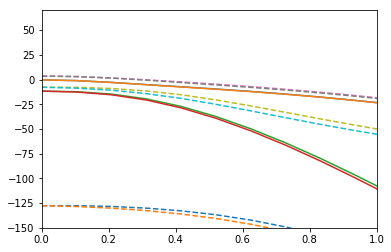

In [84]:
def _():    
    
    mesh=meshes['asgrown']
    shm,mbkp=mesh['shm'],mesh['mbkp']
    kt=mbkp._kt
    e=shm['kpen'][:,:,0]
    plt.plot(kt,e*1e3)
    
    mesh=meshes['biax_tens']
    shm,mbkp=mesh['shm'],mesh['mbkp']
    kt=mbkp._kt
    e=shm['kpen'][:,:,0]
    plt.plot(kt,e*1e3,'--')
    
    plt.ylim(-150,70)
    plt.xlim(0,1)
_()

In [35]:
meshes['uniax_comp']['m']['ex

Function([-0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0.04366259,
       -0.04366259, -0.04366259, -0.04366259, -0.04366259, -0

In [49]:
mbkp=meshes['asgrown']['mbkp']

In [24]:
mon.p.integrate(definite=True)/(1/cm**2)/1e13

Function(1.2978264354745224)

# Make GOMAC FIG

In [25]:
import matplotlib.pyplot as plt
import numpy as np
#from jxhfet.util import oldcolors; oldcolors()
from matplotlib.transforms import Bbox
from matplotlib.patches import Rectangle,Ellipse,Polygon
from matplotlib.lines import Line2D
from matplotlib.collections import PatchCollection
import matplotlib.transforms as transforms
from cycler import cycler

In [26]:
plt.rcParams['axes.linewidth']=3
plt.rcParams['lines.linewidth']=3
plt.rcParams['font.family']='sans-serif'
plt.rcParams['font.sans-serif']=['STIX']
plt.rcParams['mathtext.fontset']='stix'
plt.rcParams['font.size']=16
plt.rcParams['axes.prop_cycle'] = cycler(color='bgrcmyk')

## BD

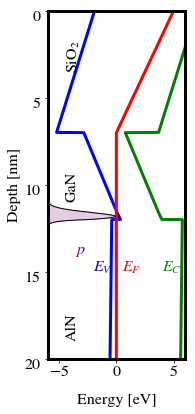

In [27]:
def fig_pFET_bd(ax):
    ax.plot(m.Ev,m.zp)
    ax.plot(m.Ec,m.zp)
    ax.plot(m.EF,m.zp)
    ax.set_yticks(np.linspace(0,20,5))
    ax.set_ylim(20,0)
    ax.set_ylabel("Depth [nm]")
    #plt.gca().yaxis.set_label_position("right")
    #plt.gca().yaxis.tick_right()
    ax.set_xlim(-6,6)
    plt.setp(ax.get_yticklabels(),va='top')
    #plt.gca().add_artist(Ellipse((-4,5.5),3,6,facecolor='none',edgecolor='k'))
    #plt.gca().add_artist(Ellipse((5,5.5),3,6,facecolor='none',edgecolor='k'))
    
    ax.set_xlabel("Energy [eV]")
    ax.xaxis.set_label_coords(.5,-.1)
    ax.text(4,15,"$E_C$",color='g',transform=ax.transData)
    ax.text(-2,15,"$E_V$",color='b',transform=ax.transData)
    ax.text(.5,15,"$E_F$",color='r',transform=ax.transData)
    
    ax2=ax.twiny()
    xmax=500
    ax2.plot(m.p*(1e7)**3/1e18,m.zp,'k',linewidth=1)
    ax2.fill_betweenx(m.zp,m.p*(1e7)**3/1e18,color='purple',alpha=.2)
    ax2.set_xlim(0,xmax)
    ax2.set_xticks([])
    ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)

    if 0:
        hl=nno.read(nno.dir+"/densities/density1Dhl"+suffix+".dat")
        el=nno.read(nno.dir+"/densities/density1Del"+suffix+".dat")
        ax2.plot(hl['hl[1e18/cm3]'],hl['position[nm]'],'k',linewidth=1)
        ax2.plot(xmax-el['el[1e18/cm3]'],el['position[nm]'],'k',linewidth=1)
        ax2.fill_betweenx(hl['position[nm]'],hl['hl[1e18/cm3]'],color='purple',alpha=.2)
        ax2.fill_betweenx(el['position[nm]'],xmax-el['el[1e18/cm3]'],x2=xmax,color='orange',alpha=.6)
        ax2.set_xlim(0,xmax)
        ax2.set_xticks([])
        ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)
        #print("hl {:.2g}x10^13/cm^2".format(np.trapz(hl['hl[1e18/cm3]']*1e18*1e-7,hl['position[nm]'])/1e13))
        #print("el {:.2g}x10^13/cm^2".format(np.trapz(el['el[1e18/cm3]']*1e18*1e-7,el['position[nm]'])/1e13))

    ax2.text(.13,.05,"AlN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    ax2.text(.13,.45,"GaN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    ax2.text(.13,.82,"SiO$_2$",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')

fig=plt.figure(figsize=(3,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_bd(ax)
plt.tight_layout()    
plt.savefig('pFET_bd.png')

## disp

In [28]:
from scipy import gradient
from scipy.interpolate import interp1d
from matplotlib.transforms import Bbox

In [29]:
def DOS_of_one(k_t,bs1_t,E):
    kt2=np.ravel(interp1d(np.ravel(bs1_t),np.ravel(k_t)**2,fill_value=0,bounds_error=False,kind='quadratic')(E))
    N=1/(2*np.pi)**2 * np.pi *kt2
    DOS=gradient(N,E[1]-E[0])
    return -DOS
E=np.linspace(.1,-.1,1200)
DOS=0

-1.09069548296e+13
-1.85888697134e+12


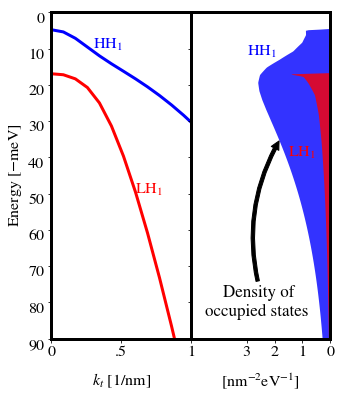

In [30]:
def fig_pFET_disp(ax):

    ax.axis('off')
    ax1=plt.axes(Bbox.from_extents(0,0,.5,1).transformed(ax.transAxes+ax.figure.transFigure.inverted()))
    ax2=plt.axes(Bbox.from_extents(.5,0,1,1).transformed(ax.transAxes+ax.figure.transFigure.inverted()),sharey=ax1)
    
    ### Dispersion plot
    
    # Plot the first two levels
    k1,e1=mbkp._kt,mbkp._mesh.kpen[:,0,0]
    ax1.plot(k1,-e1*1e3,'b',label="HH-1")
    k3,e3=mbkp._kt,mbkp._mesh.kpen[:,2,0]
    ax1.plot(k3,-e3*1e3,'r',label="LH-1")
    
    # Also plot the next level to make sure it's offscreen!
    #ax1.plot(disp_hg['k[1/nm]'],disp_hg['ev_5[eV]']*1e3,'b',label="HH-2")
    
    # Extract DOS
    DOS1=2*DOS_of_one(k1,e1,E)
    DOS3=2*DOS_of_one(k3,e3,E)
    
    # Label bands
    ax1.text(.3,10,r"HH$_1$",color='b',transform=ax1.transData)
    ax1.text(.6,50,r"LH$_1$",color='r',transform=ax1.transData)
    #ax1.text(.4,-8,r"$E_F$",color='k',transform=ax1.transData)
    ax1.axhline(0,linestyle='--',color='k')
    
    # Label axes
    ax1.yaxis.set_label_text(r"Energy [$-$meV]")
    #ax1.yaxis.set_label_coords(-.2,.72)
    ax1.xaxis.set_label_text(r"$k_t$ [1/nm]")
    ax1.xaxis.set_label_coords(.5,-.1)
    plt.setp(ax1.get_yticklabels(),va='top')
    
    # Set limits and ticks
    ax1.set_ylim(90,0);
    ax1.set_xlim(0,1)
    ax1.set_xticks([0,.5,1])
    ax1.set_xticklabels(["0",".5","1"])

    ### DOS plot
    
    # Plot occupieds
    ax2.fill_betweenx(-E*1e3,DOS1*(1/(1+np.exp(-E/.026))),0,facecolor='b',edgecolor='k',linewidth=0,alpha=.8,label='HH-1')
    ax2.fill_betweenx(-E*1e3,(DOS3)*(1/(1+np.exp(-E/.026))),0,facecolor='r',edgecolor='k',linewidth=0,alpha=.8,label='LH-1')
    ax2.axhline(0,linestyle='--',color='k')
    
    # Label and set limits
    ax2.set_xlim(5,0)
    ax2.set_xticks([0,1,2,3])
    ax2.set_xlabel("[nm$^{-2}$eV$^{-1}$]")
    ax2.xaxis.set_label_position("bottom")
    ax2.xaxis.tick_bottom()
    ax2.xaxis.set_label_coords(.5,-.1)
    plt.setp(ax2.get_yticklabels(),visible=False)

    # Label DOSs
    plt.text(3,12,r"HH$_1$",color='b')
    plt.text(1.5,40,r"LH$_1$",color='r')

    plt.annotate("Density of\noccupied states ",(1.8,35),xytext=(2.57,80),ha='center',va='center',fontsize=17,
                 arrowprops=dict(arrowstyle='simple',color='k',connectionstyle='arc3,rad=-.2',relpos=(.5,1)))

    print(np.trapz(DOS1*(1/(1+np.exp(-E/.026))),E)*1e14)
    print(np.trapz(DOS3*(1/(1+np.exp(-E/.026))),E)*1e14)
    
fig=plt.figure(figsize=(5,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_disp(ax)
#plt.tight_layout()
plt.savefig("pFET_disp.png")

In [31]:
kT=k*shm.T
eta=(shm.kpen-shm.EF)/kT.tpf()
np.trapz(np.sum(1/(2*np.pi)*np.trapz(mbkp._kt*(mbkp._normsqs/(1+np.exp(-eta))).T,x=mbkp._kt),axis=1),shm.zp)

Function(0.12978264371889187)

In [20]:
m.p.integrate(definite=True)

Function(0.12943258654777484)

-1.10522783612e+13
-1.67788816217e+12


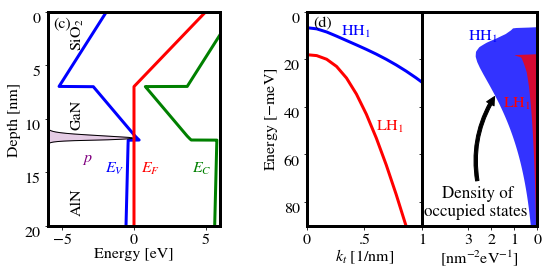

In [23]:
fig=plt.figure(figsize=(8,3.5),frameon=False)
ax1=fig.add_axes(plt.Axes(plt.gcf(),[.1,.15,.3,.85]))
ax2=fig.add_axes(plt.Axes(plt.gcf(),[.55,.15,.4,.85]))
fig_pFET_bd(ax1)
fig_pFET_disp(ax2)
ax1.text(.03,.93,"(c)",transform=ax1.transAxes)
ax2.figure.axes[-1].text(.03,.93,"(d)",transform=ax2.transAxes)
plt.savefig("pFET_theory.png")

# pixie

In [6]:
import pixiedust

Pixiedust database opened successfully


In [7]:
%%pixie_debugger